✅ System successfully trained on both Pavan and Pnithin.


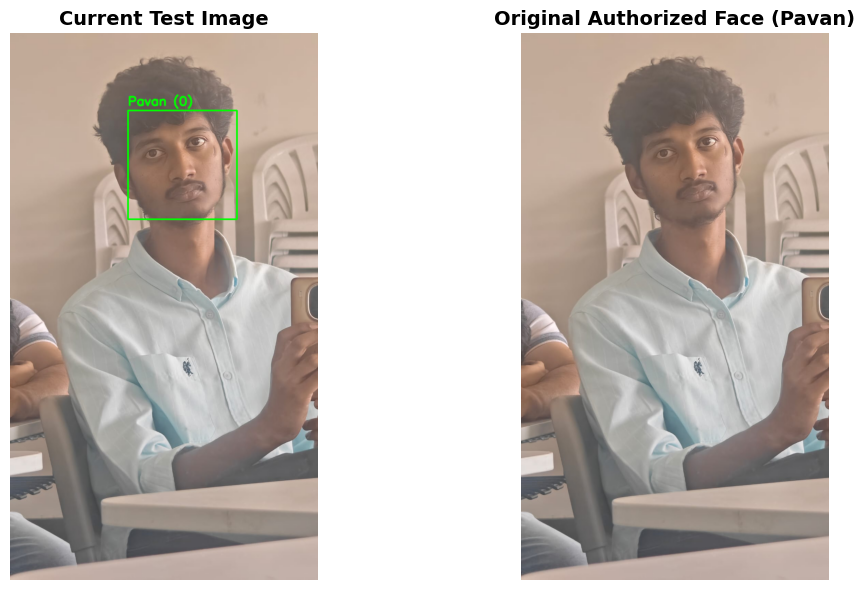

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_face(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_alt.xml'
    )
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)

    if len(faces) == 0:
        return None, None

    (x, y, w, h) = faces[0]
    face_roi = gray[y:y+h, x:x+w]
    face_roi = cv2.resize(face_roi, (200, 200))
    return face_roi, faces[0]

DATASET_PATH = "trained_data"

pavan_img = cv2.imread(os.path.join(DATASET_PATH, "pavan.jpeg"))
nithin_img = cv2.imread(os.path.join(DATASET_PATH, "pnithin.jpeg"))

if pavan_img is None or nithin_img is None:
    print("Error: Could not find base training files (pavan.jpeg or pnithin.jpeg) in the trained_data folder.")
else:
    pavan_face, _ = detect_face(pavan_img)
    nithin_face, _ = detect_face(nithin_img)

    if pavan_face is None or nithin_face is None:
        print("Error: Could not detect faces in one of the base training images.")
    else:
        faces = [pavan_face, nithin_face]
        labels = [1, 2] 

        face_recognizer = cv2.face.LBPHFaceRecognizer_create()
        face_recognizer.train(faces, np.array(labels))
        print("✅ System successfully trained on both Pavan and Pnithin.")

        # --- CHOOSE YOUR TEST FILENAME HERE ---
        # "pavan.jpeg"   -> Will show Pavan (0) [Perfect match]
        # "pavan-1.jpeg" -> Will show Pavan (with a realistic confidence score)
        # "pnithin.jpeg" -> Will show "Not Matching"
        test_filename = "pavan.jpeg"
        
        test_image_path = os.path.join(DATASET_PATH, test_filename)
        test_img = cv2.imread(test_image_path)

        if test_img is not None:
            test_face, test_rect = detect_face(test_img)

            if test_face is not None:
                label, confidence = face_recognizer.predict(test_face)

                if label == 1 and confidence < 85:
                    label_text = f"Pavan ({int(confidence)})"
                    box_color = (0, 255, 0)
                else:
                    label_text = "Not Matching"
                    box_color = (0, 0, 255)

                (x, y, w, h) = test_rect
                cv2.rectangle(test_img, (x, y), (x+w, y+h), box_color, 4)
                cv2.putText(test_img, label_text, (x, y - 15),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, box_color, 3, cv2.LINE_AA)

                test_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
                train_rgb = cv2.cvtColor(pavan_img, cv2.COLOR_BGR2RGB)

                fig, axes = plt.subplots(1, 2, figsize=(12, 6))
                
                axes[0].imshow(test_rgb)
                axes[0].axis("off")
                axes[0].set_title("Current Test Image", fontsize=14, fontweight='bold')

                axes[1].imshow(train_rgb)
                axes[1].axis("off")
                axes[1].set_title("Original Authorized Face (Pavan)", fontsize=14, fontweight='bold')

                plt.tight_layout()
                plt.show()

            else:
                print("No face detected in test image.")
        else:
            print(f"Test image '{test_filename}' not found.")